# Introduction

<center>
<h2>
Computational Experiments with Modern Parametrized Gaussian Error Linear Unit (MPGELU)
</h2>
<b>A demonstration by: Jose Aries E. De Los Santos</b>
</center>

# Import Libraries

In [2]:
import os
import sys
from pathlib import Path

#PyTorch
import torch as torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
import time 
from torchinfo import summary

import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import random
from typing import Iterable, Callable


#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Import torchvision
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchinfo import summary

#Import tqdm for a cool progress bar
from tqdm.auto import tqdm

# Measure time
from timeit import default_timer as timer

seed = 143
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


print(f"PyTorch Version: {torch.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
# print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"SciPy Version: {scipy.__version__}")

# device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    device = "cuda"
    print(f"Device: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print(f"Device: {torch.backends.mps.is_available()}")
else:
    device = "cpu"
    print(f"Device: {device}")  

PyTorch Version: 2.2.2
Numpy Version: 1.26.4
Pandas Version: 3.0.0
SciPy Version: 1.17.0
Device: NVIDIA GeForce RTX 2050


# Dynamic Path Modification

* It is a runtime technique used to explicitly tell Python where to look for modules or packages when you run an ``import`` statement.

## Import Helper Functions

In [10]:
### Add the parent directory to the sys.path to import MyCNN and MPGELU
%reload_ext autoreload
%autoreload 2
mother_path = Path.cwd()
for folder in ["utility", "act_fns", "models"]:
    path = os.path.join(mother_path , folder)
    if path not in sys.path:
        sys.path.append(path)
from MPGELU import MPGELU
from PGELU import PGELU
from MyCNN import MyCNN
from DataTransforms import DataTransforms
from Trainer import Trainer
from LoadedModel import LoadedModel

# MP GELU

* Modified Parametric Gaussian Error Linear Unit 
$$
f(x) = \frac{x}{2} \left[ 1 + \text{erf}\left( \frac{\lambda x}{\sqrt{2}}\right)\right] = \frac{x}{2} + \frac{x}{\sqrt{\pi}}\int_{0}^{\lambda x / \sqrt{2}} e^{-u^{2}}du
$$
where $\lambda  = (1 + \ln(1 + e^{s})) \geq 1$   $\forall s \in \mathbb{R}$

* Check MPGELU.py file for the implementation of the MPGELU activation function

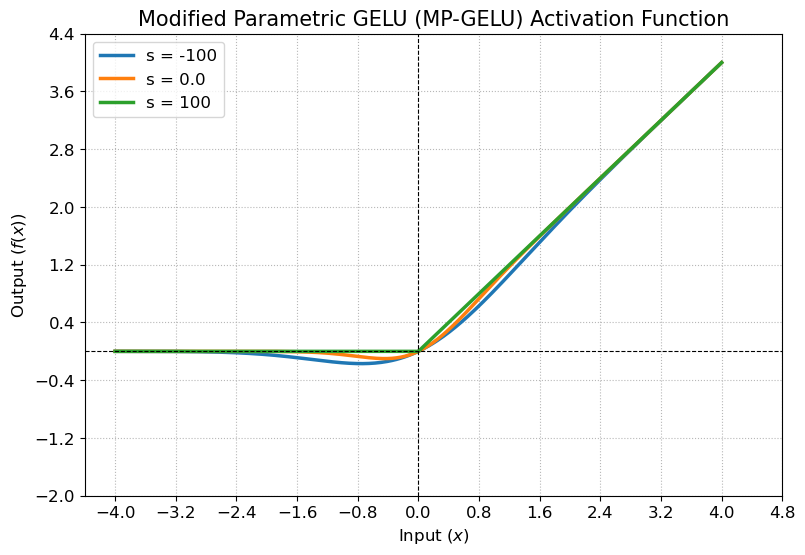

In [3]:
x_np = np.linspace(-4.0, 4.0, 400)
x_tensor = torch.tensor(x_np, dtype=torch.float32)
# s_values = np.arange(-2.0, 2.0, 0.1)
s_values = [-100, 0.0, 100, ]
plt.figure(figsize=(9, 6))

for s_val in s_values:
    activation1 = MPGELU(s_param=s_val)
    activation2 = MPGELU(s_param=s_val, use_softplus=False)
    with torch.no_grad():
        y_tensor1 = activation1(x_tensor)
        y_tensor2 = activation2(x_tensor)

    lam_val = (1.0 + F.softplus(torch.tensor(s_val, dtype=torch.float32))).item()
    plt.plot(x_np, y_tensor1.numpy(), label=f"s = {s_val}", linewidth=2.5)
    # plt.plot(x_np, y_tensor2.numpy(), label=f"s = {s_val}", linewidth=2)

# 4. Format the plot
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Modified Parametric GELU (MP-GELU) Activation Function", fontsize=15)
xticks = np.arange(-4, 5, 0.8)
plt.xticks(xticks,fontsize=12)
plt.xlabel("Input ($x$)", fontsize=12)
yticks = np.arange(-2, 5, 0.8)
plt.yticks(yticks,fontsize=12)
plt.ylabel("Output ($f(x)$)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.9)
plt.legend(fontsize=12)
plt.show()


# Data Processing

In [ ]:
transformer = DataTransforms(dataset='cifar10', use_augmentation=True, use_stats=False)
train_transform = transformer.get_train_transform()
test_transform = transformer.get_test_transform()


train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)


train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

Files already downloaded and verified
Files already downloaded and verified


## Visualize Sample Images

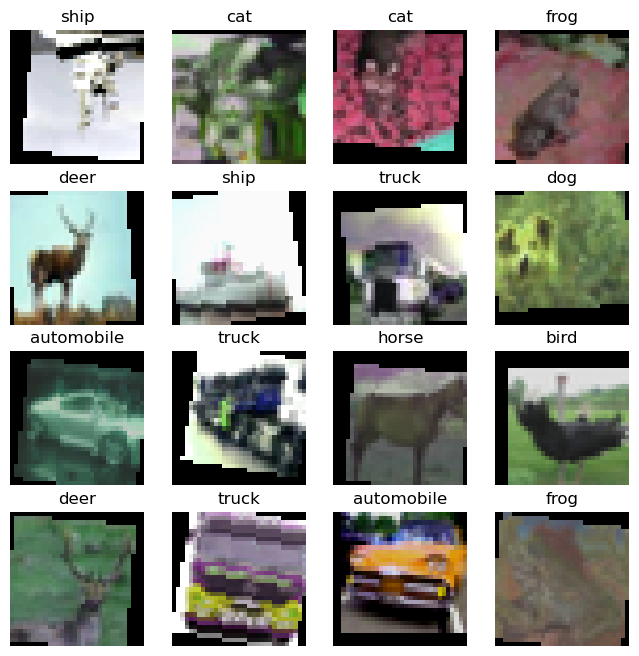

In [12]:
fig = plt.figure(figsize=(8, 8))
rows, columns = 4, 4

for i in range(1, rows * columns + 1):
    idx = torch.randint(0, len(train_data), size=[1]).item()  # Random index
    img, label = train_data[idx][0], train_data[idx][1]
    fig.add_subplot(rows, columns, i)
    
    # Display image without converting to grayscale
    plt.imshow(img.permute(1, 2, 0))  # Change channels to last dimension (H, W, C)
    plt.title(train_data.classes[label])
    plt.grid(False)
    plt.axis(False)

plt.axis(False)
# plt.savefig("cifar10_dataset.jpg",dpi=800, bbox_inches="tight")
plt.show()

# Model

## Set its Parameters

In [13]:
chosen_model_params = [32, 32, 'MaxPool', 64, 64, 'MaxPool', 128, 128, 128, 'MaxPool']

model = MyCNN(input_shape=3,
                  output_shape=10,
                  activation = MPGELU,
                  params = chosen_model_params).to(device)

print(summary(model=model,
        input = torch.randn(size=(3, 32, 32)).unsqueeze(dim=0)))

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Layer (type:depth-idx)                   Param #
MyCNN                                    --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─MPGELU: 2-2                       1
│    └─Conv2d: 2-3                       9,248
│    └─MPGELU: 2-4                       1
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       18,496
│    └─MPGELU: 2-7                       1
│    └─Conv2d: 2-8                       36,928
│    └─MPGELU: 2-9                       1
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      73,856
│    └─MPGELU: 2-12                      1
│    └─Conv2d: 2-13                      147,584
│    └─MPGELU: 2-14                      1
│    └─Conv2d: 2-15                      147,584
│    └─MPGELU: 2-16                      1
│    └─MaxPool2d: 2-17                   --
├─Sequential: 1-2                        --
│    └─Linear: 2-18                      524,544
│  

## Test Dummy Input

In [14]:
dummy_input = torch.randn(1, 3, 32, 32).to(device)
model(dummy_input)

tensor([[-0.0304,  0.0399,  0.0075, -0.0525, -0.0390, -0.0106,  0.0100,  0.0583,
          0.0522, -0.0437]], device='cuda:0', grad_fn=<AddmmBackward0>)

# Training and Execution

## Setup loss, accuracy, and paramaters

## Mathematical Definition of Categorical Cross-Entropy

Categorical Cross-Entropy (CCE) is the standard loss function for multi-class classification. It measures the difference between two probability distributions: the actual ground-truth labels (usually one-hot encoded) and the model's predicted probabilities.

For a single sample, the loss is defined as:

$$f(y_i, \hat{y}_i) = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

When calculating the average loss over a batch of $N$ samples, the formula expands to:

$$f(y_i, \hat{y}_i) = -\frac{1}{N} \sum_{j=1}^{N} \sum_{i=1}^{C} y_{j,i} \log(\hat{y}_{j,i})$$

**Where:**
* $C$ = Total number of classes
* $N$ = Total number of samples in the batch
* $y_i$ (or $y_{j,i}$) = The true label (1 if the sample belongs to class $i$, and 0 for all other classes)
* $\hat{y}_i$ (or $\hat{y}_{j,i}$) = The model's predicted probability that the sample belongs to class $i$ (typically the output of a Softmax activation function)

> **Note:** Because the true labels $y_i$ are zero for all incorrect classes in one-hot encoding, the formula effectively simplifies to taking the negative log of the predicted probability for the **true** class.

In [15]:
#Setup Loss Functions, Accuracy function
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

#Define Accuracy Metric
def calculate_accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = (correct / len(y_pred)) * 100
  return accuracy

##Training Parameters

num_of_epochs = 10
num_loss_steps = 1


### Gradient Norm

**Mathematical Definition**: The $\ell^2$ Norm of the Gradient. In real analysis, the small $\ell^2$ norm (standard Euclidean norm) measures the magnitude of a finite-dimensional vector in $\mathbb{R}^n$.Let $\mathbf{w} \in \mathbb{R}^n$ represent the flattened continuous vector of all trainable parameters within the neural network architecture. The gradient of the objective loss function $\mathcal{L}$ with respect to these parameters is a discrete vector composed of partial derivatives:
$$\nabla_{\mathbf{w}} \mathcal{L} = \left[ \frac{\partial \mathcal{L}}{\partial w_1}, \frac{\partial \mathcal{L}}{\partial w_2}, \dots, \frac{\partial \mathcal{L}}{\partial w_n} \right]^T$$

The $\ell^2$ norm of this gradient vector, denoted as $\Vert{} \nabla_{\mathbf{w}} \mathcal{L} \Vert{}_{\ell^2}$ or simply $\Vert{} \nabla_{\mathbf{w}} \mathcal{L} \Vert{}_2$, is defined as the square root of the sum of its squared coordinate components:$$\Vert{} \nabla_{\mathbf{w}} \mathcal{L} \Vert{}_2 = \sqrt{ \sum_{i=1}^{n} \left( \frac{\partial \mathcal{L}}{\partial w_i} \right)^2 }$$In the context of empirical risk minimization, bounding this sequence of finite sums guarantees that gradient updates remain stable and prevents the parameter vector from diverging during optimization.


**IMPORTANT NOTE**

In real and functional analysis, the capital $L^p$ spaces denote spaces of measurable functions, where the norm is evaluated via continuous integration, such as $\Vert{}f\Vert{}_{L^2} = \left( \int \vert{}f(x)\vert{}^2 dx \right)^{1/2}$. The lowercase $\ell^p$ spaces apply to discrete sequences or finite-dimensional coordinate vectors, where the norm is evaluated via discrete summation. Since the gradient of a neural network's loss with respect to its parameters, $\nabla_{\mathbf{w}} \mathcal{L}$, is a finite-dimensional vector of discrete scalar derivatives rather than a continuous mathematical function, finding its magnitude requires summing the squares of its individual components. You are completely correct: we use the small $\ell^2$ norm precisely because we are operating on discrete Euclidean vectors, not continuous functions.

## Execution and Saving

In [ ]:
torch.manual_seed(143)
activation_dict = {
    "PGELU": PGELU,
    # "MP_GELU": MPGELU,
    # "ReLU": torch.nn.ReLU,
    # "GELU": torch.nn.GELU,
    # "LeakyReLU": torch.nn.LeakyReLU
}

all_results = {}

for act_name, act_fn in activation_dict.items():
    print(f"\n=======================================================")
    print(f"       TRAINING WITH ACTIVATION: {act_name}")
    print(f"=======================================================")
    
    model = MyCNN(input_shape=3, output_shape=10, activation=act_fn, params=chosen_model_params).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    trainer = Trainer(model=model, loss_fn=loss_fn, optimizer=optimizer, 
                      calculate_accuracy=calculate_accuracy, device=device, loss_steps=num_loss_steps)
    
    results = {
        "train_loss": [], 
        "train_accu": [],
        "test_loss": [], 
        "test_accu": [],
        "activation_params": {},
        "grad_norm": []  # Initialize an empty list to store gradient norms
    }
    
    start_time = time.perf_counter()
    
    for epoch in tqdm(range(num_of_epochs), desc=f"Training {act_name}"):
        if epoch % num_loss_steps == 0:
            print(f"Epoch: {epoch} \n =====================================================================")
        train_loss, train_accu, norm = trainer.train(data_loader=train_dataloader, epoch=epoch)
        test_loss, test_accu = trainer.test(data_loader=test_dataloader, epoch=epoch)
        
        results["train_loss"].append(train_loss)
        results["train_accu"].append(train_accu)
        results["test_loss"].append(test_loss)
        results["test_accu"].append(test_accu)
        results["grad_norm"].append(norm) 
        
        # Track dynamic activation parameters
        for name, param in model.named_parameters():
            if 'alpha_param' in name or 'beta_param' in name or 's_param' in name:
                if name not in results.setdefault("activation_params", {}):
                    results["activation_params"][name] = []
                results["activation_params"][name].append(param.item())
                
    total_time = time.perf_counter() - start_time
    results["total_runtime"] = total_time
    all_results[act_name] = results
    
    # Save Model Checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'results': results,
        'total_runtime': total_time,
        'activation_name': act_name 
    }
    
    save_dir = "model_trained_params_new"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"chkpt3_{act_name}.pth")
    
    torch.save(checkpoint, save_path)
    print(f"Saved model state to {save_path}")

# Loading the trained model params


In [8]:
activation_dict = {
    "MP_GELU": MPGELU,
    "PGELU": PGELU,
    "ReLU": torch.nn.ReLU,
    "GELU": torch.nn.GELU,
    "LeakyReLU": torch.nn.LeakyReLU
}


# Initialize LoadedModel with the correct initial_fileName and checkpoint_dir
loader = LoadedModel(
    activation_dict=activation_dict,
    model_params=chosen_model_params,
    initial_fileName="chkpt2",
    checkpoint_dir="model_trained_params_new",
    device=device
)

# Run it
my_models = loader.load_checkpoints()


       EVALUATING ACTIVATION: MP_GELU
Loaded trained model for MP_GELU from model_trained_params_new/chkpt2_MP_GELU.pth

       EVALUATING ACTIVATION: PGELU
Loaded trained model for PGELU from model_trained_params_new/chkpt2_PGELU.pth

       EVALUATING ACTIVATION: ReLU
Loaded trained model for ReLU from model_trained_params_new/chkpt2_ReLU.pth

       EVALUATING ACTIVATION: GELU
Loaded trained model for GELU from model_trained_params_new/chkpt2_GELU.pth

       EVALUATING ACTIVATION: LeakyReLU
Loaded trained model for LeakyReLU from model_trained_params_new/chkpt2_LeakyReLU.pth


# Evaluation

## Plotting

In [9]:
to_plot = {
    "MP_GELU":   {"results": my_models["MP_GELU"]["results"],   "linewidth": 3.0, "color": "#000000"}, # Jet Black 
    "PGELU":     {"results": my_models["PGELU"]["results"],     "linewidth": 2.0, "color": "#E62937"}, # Strong Red
    "ReLU":      {"results": my_models["ReLU"]["results"],      "linewidth": 2.0, "color": "#009E73"}, # Teal 
    "GELU":      {"results": my_models["GELU"]["results"],      "linewidth": 2.0, "color": "#4363D8"}, # Royal Blue 
    "LeakyReLU": {"results": my_models["LeakyReLU"]["results"], "linewidth": 2.0, "color": "#F58231"}  # Bright Orange
}

### Evolution of Learnable Parameters

#### $\alpha$ and $\beta$ of PGELU 

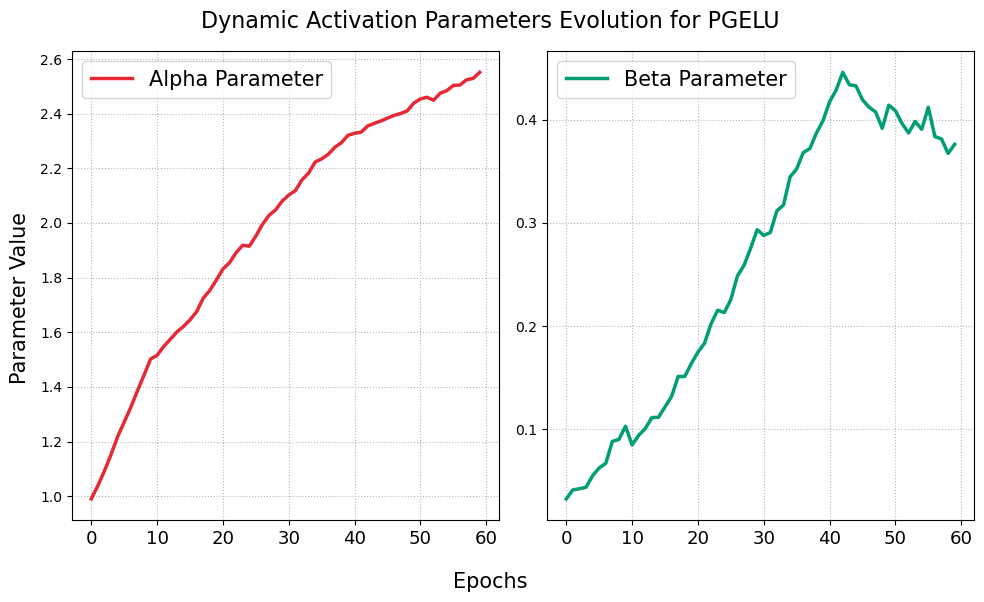

In [10]:
alpha = my_models["PGELU"]["results"]["activation_params"]["conv_layers.1.alpha_param"]
beta = my_models["PGELU"]["results"]["activation_params"]["conv_layers.1.beta_param"]

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
# Alpha Plot
ax[0].plot(alpha, label="Alpha Parameter", color="#E62937", linewidth=2.5)
# ax[0].set_title("Alpha Parameter Evolution", fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.9)
ax[0].tick_params(axis='x', labelsize=13) 
ax[0].legend(fontsize=15)
# Beta Plot
ax[1].plot(beta, label="Beta Parameter", color="#009E73", linewidth=2.5)
# ax[1].set_title("Beta Parameter Evolution", fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.9)
ax[1].tick_params(axis='x', labelsize=13) 
ax[1].legend(fontsize=15) 


fig.supxlabel("Epochs", fontsize=15)
fig.supylabel("Parameter Value", fontsize=15)
fig.suptitle("Dynamic Activation Parameters Evolution for PGELU", fontsize=16)

plt.tight_layout()
plt.show()

#### $\lambda$ of MPGELU 

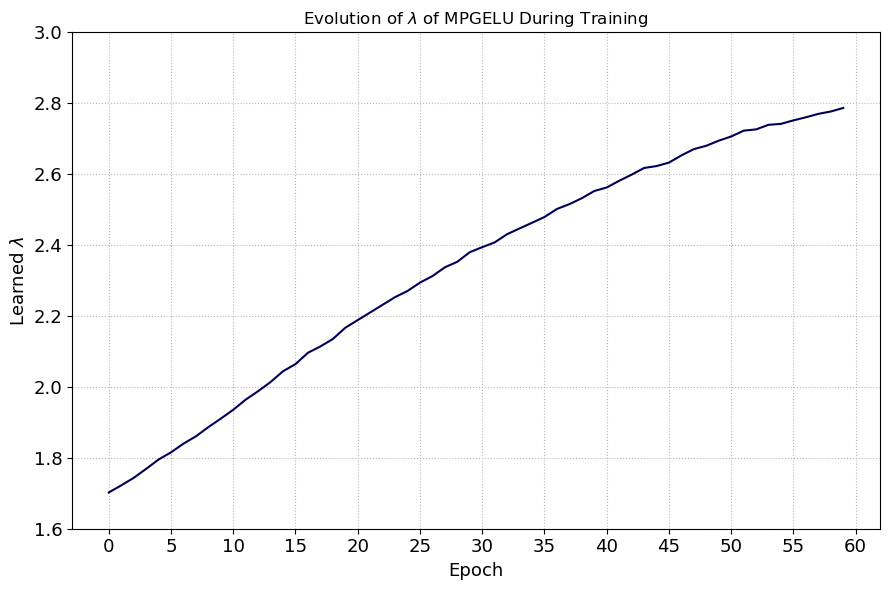

In [11]:
params_dict = my_models["MP_GELU"]["results"]["activation_params"]
s_vals = params_dict['conv_layers.1.s_param']
s_values = torch.tensor(s_vals, device=device, dtype=torch.float32)
lam = 1.0 + torch.log(1.0 + torch.exp(s_values))
plt.figure(figsize=(9, 6))
plt.plot(lam.detach().cpu().numpy(), linestyle='-', color='#000055')
plt.xlabel("Epoch", fontsize=13)
plt.ylabel(r"Learned $\lambda$", fontsize=13)
plt.title(r"Evolution of $\lambda$ of MPGELU During Training")
plt.grid(True, linestyle=':', alpha=0.9)
plt.yticks(np.arange(1.6, 3.2, 0.2), fontsize=13)
plt.xticks(np.arange(0, 65, 5), fontsize=13)
plt.tight_layout()
# plt.savefig("learned_lambda_evolution.jpg", dpi=800, bbox_inches="tight")
plt.show()

### Train Loss Curves

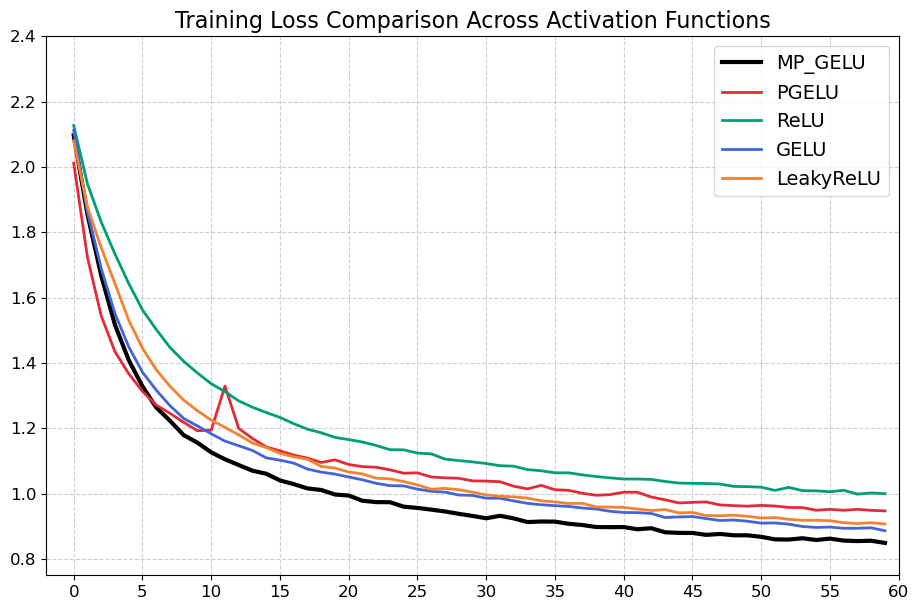

In [12]:
plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]
    arguments = {
        "linewidth" : property.get("linewidth",1.0), 
        "linestyle": property.get("linestyle"),
        "label": act_name,
        "color": property["color"]
    }
    plt.plot(plot_results["train_loss"], **arguments)
plt.legend(loc="upper right", fontsize=14)
plt.grid(True,linestyle='--', alpha=0.6)
plt.xticks(np.arange(-10,65,5), fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.75,2.4)
plt.xlim(-2,60)
plt.title("Training Loss Comparison Across Activation Functions", fontsize=16)
# plt.savefig("train_loss_comparison.jpg", dpi=800, bbox_inches="tight")
plt.show()

### Test Loss Curves

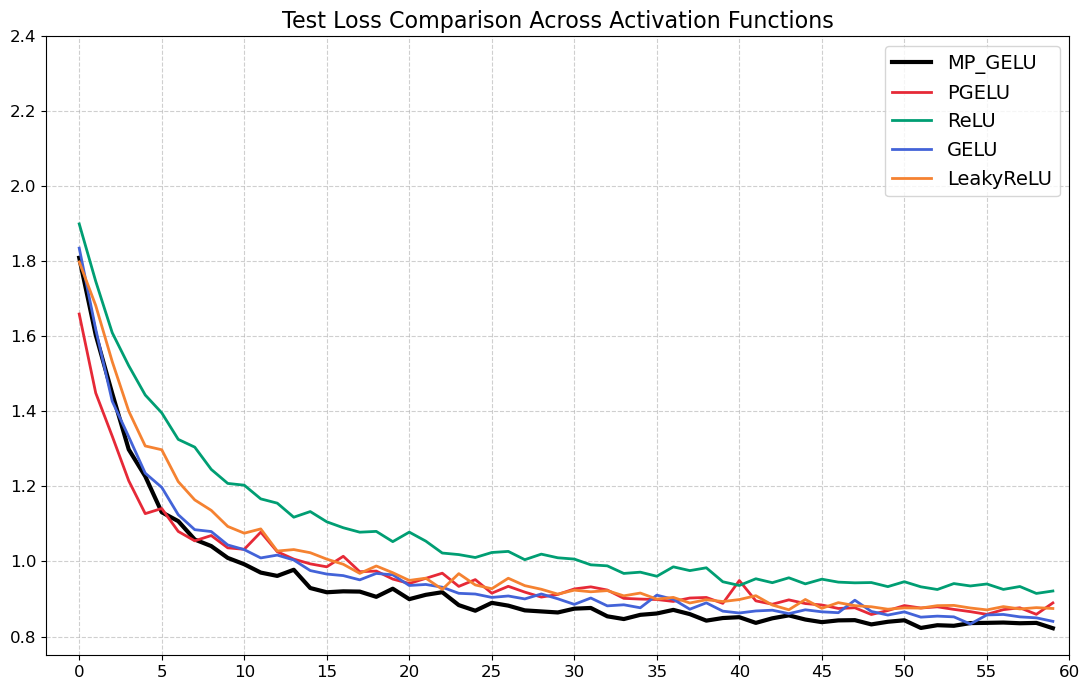

In [23]:
plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]
    arguments = {
        "linewidth" : property.get("linewidth",1.0), 
        "linestyle": property.get("linestyle"),
        "label": act_name,
        "color": property["color"]
    }
    plt.plot(plot_results["test_loss"], **arguments)
plt.legend(loc="upper right", fontsize=14)
plt.grid(True,linestyle='--', alpha=0.6)
plt.xticks(np.arange(-10,65,5), fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.75,2.4)
plt.xlim(-2,60)
plt.title("Test Loss Comparison Across Activation Functions", fontsize=16)
plt.tight_layout()
# plt.savefig("test_loss_comparison.jpg", dpi=800, bbox_inches="tight")
plt.show()

### Training Accuracy

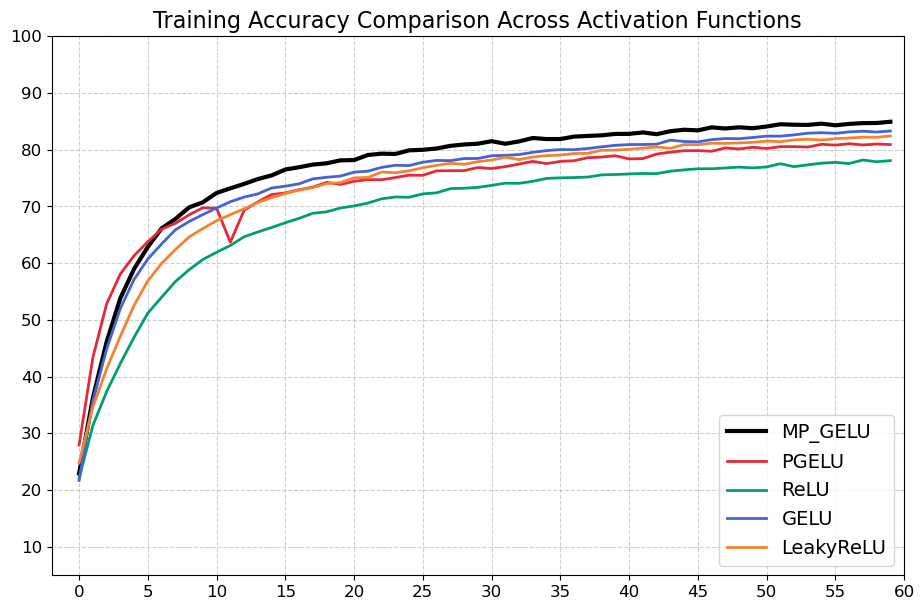

In [27]:
plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]
    arguments = {
        "linewidth" : property.get("linewidth",1.0), 
        "linestyle": property.get("linestyle"),
        "label": act_name,
        "color": property["color"]
    }
    plt.plot(plot_results["train_accu"], **arguments)
plt.legend(loc="lower right", fontsize=14)
plt.grid(True,linestyle='--', alpha=0.6)
plt.xticks(np.arange(-5,65,5), fontsize=12)
plt.yticks(np.arange(0,110,10), fontsize=12)
plt.ylim(5,100)
plt.xlim(-2,60)
plt.title("Training Accuracy Comparison Across Activation Functions", fontsize=16)
plt.show()

### Test Accuracy

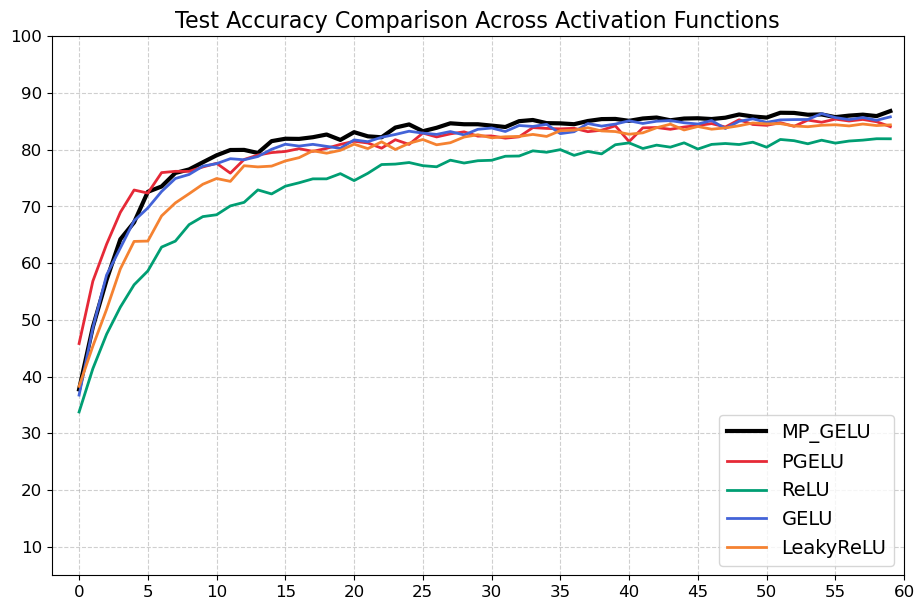

In [26]:
plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]
    arguments = {
        "linewidth" : property.get("linewidth",1.0), 
        "linestyle": property.get("linestyle"),
        "label": act_name,
        "color": property["color"]
    }
    plt.plot(plot_results["test_accu"], **arguments)
plt.legend(loc="lower right", fontsize=14)
plt.grid(True,linestyle='--', alpha=0.6)
plt.xticks(np.arange(-5,65,5), fontsize=12)
plt.yticks(np.arange(0,110,10), fontsize=12)
plt.ylim(5,100)
plt.xlim(-2,60)
plt.title("Test Accuracy Comparison Across Activation Functions", fontsize=16)
plt.show()

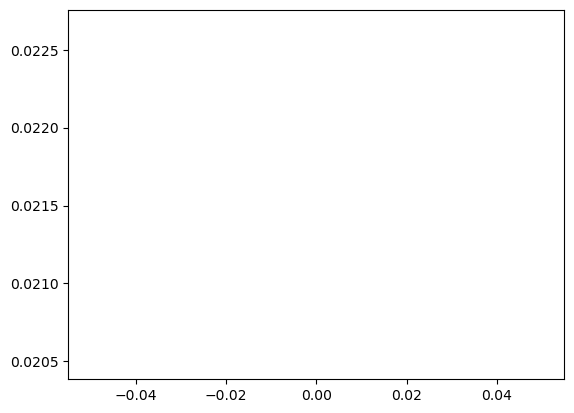

In [23]:
plt.plot(my_models["PGELU"]["results"]["grad_norm"])

# $F_{1}$ Scores
**Mathematical Definition of the $F_1$ Score**

The $F_1$ score is the harmonic mean of Precision and Recall. It provides a single metric that balances both false positives and false negatives, making it particularly useful for evaluating models on imbalanced datasets.

The general formula is defined as:

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

To calculate the $F_1$ score, you must first calculate **Precision** and **Recall**:

* **Precision** measures the proportion of positive predictions that were actually correct:
  $$\text{Precision} = \frac{TP}{TP + FP}$$

* **Recall** (also known as Sensitivity) measures the proportion of actual positives that were identified correctly:
  $$\text{Recall} = \frac{TP}{TP + FN}$$

By substituting Precision and Recall back into the original equation, the $F_1$ score can be expressed directly in terms of prediction outcomes:

$$F_1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

**Where:**
* $TP$ = **True Positives** (Model correctly predicts the positive class)
* $FP$ = **False Positives** (Model incorrectly predicts the positive class)
* $FN$ = **False Negatives** (Model incorrectly predicts the negative class)

In [28]:
f1_results = {}

print("Calculating F1 Scores...")
print("========================")

for act_name, model_data in my_models.items():
    model = model_data["model"]
    model.eval()  # Ensure the model is in evaluation mode
    
    all_preds = []
    all_targets = []
    
    with torch.inference_mode():
        # Assuming you have your test_dataloader ready
        for inputs, targets in test_dataloader:
            inputs = inputs.to(device)
            
            # Get predictions
            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())  
            
    f1 = f1_score(all_targets, all_preds, average='macro')
    f1_results[act_name] = f1
    
    print(f"{act_name: >10}: {f1:.4f}")

Calculating F1 Scores...
   MP_GELU: 0.8669
     PGELU: 0.8390
      ReLU: 0.8189
      GELU: 0.8577
 LeakyReLU: 0.8417
